# Examen 1 Bimestre - Recuperación de Información

Nombre: Anthony Goyes

In [1]:
!pip install sentence-transformers kaggle

In [3]:
import zipfile

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

In [4]:
import os

os.listdir("data")


['rotten_tomatoes_critic_reviews.csv', 'rotten_tomatoes_movies.csv']

In [5]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

## Carga del corpus

Se utiliza el dataset Rotten Tomatoes Movies and Critic Reviews.  
Cada documento representa una película con información textual relacionada.

In [9]:
movies_path = "data/rotten_tomatoes_movies.csv"
reviews_path = "data/rotten_tomatoes_critic_reviews.csv"

movies = pd.read_csv(movies_path)
reviews = pd.read_csv(reviews_path)

print("Movies:", movies.shape)
print("Reviews:", reviews.shape)

movies.head()

Movies: (17712, 22)
Reviews: (1130017, 8)


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3


Revisar columnas

In [10]:
print(movies.columns)
print(reviews.columns)

Index(['rotten_tomatoes_link', 'movie_title', 'movie_info',
       'critics_consensus', 'content_rating', 'genres', 'directors', 'authors',
       'actors', 'original_release_date', 'streaming_release_date', 'runtime',
       'production_company', 'tomatometer_status', 'tomatometer_rating',
       'tomatometer_count', 'audience_status', 'audience_rating',
       'audience_count', 'tomatometer_top_critics_count',
       'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count'],
      dtype='object')
Index(['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name',
       'review_type', 'review_score', 'review_date', 'review_content'],
      dtype='object')


Construir documentos

In [11]:
movies = movies.fillna("")

movies["document_text"] = (
    movies["movie_title"].astype(str) + " " +
    movies["movie_info"].astype(str) + " " +
    movies["critics_consensus"].astype(str) + " " +
    movies["genres"].astype(str) + " " +
    movies["directors"].astype(str) + " " +
    movies["actors"].astype(str)
)

df = movies[["rotten_tomatoes_link", "movie_title", "document_text"]].copy()

df = df.drop_duplicates(subset=["rotten_tomatoes_link"])
df = df.reset_index(drop=True)

print("Documentos:", df.shape)
df.head()

Documentos: (17712, 3)


,rotten_tomatoes_link,movie_title,document_text
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Percy Jackson & the Olympians: The Lightning T...
1,m/0878835,Please Give,Please Give Kate (Catherine Keener) and her hu...
2,m/10,10,"10 A successful, middle-aged Hollywood songwri..."
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),12 Angry Men (Twelve Angry Men) Following the ...
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","20,000 Leagues Under The Sea In 1866, Professo..."


## Preprocesamiento

Se realiza conversión a minúsculas, eliminación de puntuación y eliminación de espacios redundantes para reducir ruido textual.

In [12]:
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-zA-Z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["texto_limpio"] = df["document_text"].apply(limpiar_texto)

print(df["texto_limpio"].iloc[0][:500])

percy jackson the olympians the lightning thief always trouble prone the life of teenager percy jackson logan lerman gets a lot more complicated when he learns he s the son of the greek god poseidon at a training ground for the children of deities percy learns to harness his divine powers and prepare for the adventure of a lifetime he must prevent a feud among the olympians from erupting into a devastating war on earth and rescue his mother from the clutches of hades god of the underworld though


Tomar una muestra

In [13]:
df = df.sample(n=min(3000, len(df)), random_state=42).reset_index(drop=True)

print("Documentos usados:", len(df))

Documentos usados: 3000


## Generación de embeddings

Se utiliza el modelo all-MiniLM-L6-v2 de Sentence Transformers para convertir cada documento en un vector semántico.

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

documentos = df["texto_limpio"].tolist()

embeddings_docs = model.encode(
    documentos,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Shape embeddings:", embeddings_docs.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Shape embeddings: (3000, 384)


Función de búsqueda por similitud coseno

In [15]:
def buscar(query, top_k=5):
    query_limpia = limpiar_texto(query)

    embedding_query = model.encode(
        [query_limpia],
        normalize_embeddings=True
    )

    similitudes = cosine_similarity(embedding_query, embeddings_docs).flatten()

    indices = similitudes.argsort()[::-1][:top_k]

    resultados = []

    for rank, idx in enumerate(indices, start=1):
        resultados.append({
            "Ranking": rank,
            "ID documento": df.iloc[idx]["rotten_tomatoes_link"],
            "Título película": df.iloc[idx]["movie_title"],
            "Fragmento de texto": df.iloc[idx]["document_text"][:250],
            "Similitud": similitudes[idx]
        })

    return pd.DataFrame(resultados)

## Recuperación de información

Para cada consulta se calcula similitud coseno entre el embedding de la query y los embeddings de los documentos.

### Consultas obligatorias


In [16]:
queries = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences"
}

### Ejecutar Top-k por consulta

In [17]:
resultados_por_query = {}

for qid, query in queries.items():
    print("=" * 100)
    print(qid, ":", query)
    print("=" * 100)

    resultados = buscar(query, top_k=5)
    resultados_por_query[qid] = resultados

    display(resultados)

Q1 : science fiction movie with advanced technology


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/side_by_side_2012,Side by Side,"Side by Side Directors James Cameron, David Fi...",0.422486
1,2,m/the_machine_2013,The Machine,The Machine Two scientists fall in love while ...,0.413235
2,3,m/1205483_nine,9,"9 When 9 (Elijah Wood) springs to life, it fin...",0.394135
3,4,m/planet_51,Planet 51,"Planet 51 When astronaut Capt. Charles ""Chuck""...",0.389554
4,5,m/iron_giant,The Iron Giant,The Iron Giant In this animated adaptation of ...,0.385197


Q2 : romantic story with emotional relationships


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/a_ghost_story,A Ghost Story,"A Ghost Story A passionate young couple, unexp...",0.520876
1,2,m/the-romantics,The Romantics,The Romantics Longtime rivalries resurface in ...,0.498523
2,3,m/soulmate_2016,SoulMate,SoulMate A woman's life is disrupted when a bo...,0.472273
3,4,m/romantics_anonymous,Romantics Anonymous,Romantics Anonymous A chocolate maker falls in...,0.464396
4,5,m/a_novel_romance,A Novel Romance,A Novel Romance Nate (Steve Guttenberg) and Je...,0.459421


Q3 : action movie with intense fight scenes


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/taking_sides_le_cas_furtwangler,Taking Sides: Le cas Furtwängler,"Taking Sides: Le cas Furtwängler A complex, w...",0.439441
1,2,m/edmond,Edmond,Edmond Seemingly mild-mannered businessman Edm...,0.424751
2,3,m/an_affair_of_the_heart,An Affair of the Heart,An Affair of the Heart Filmmaker Sylvia Camine...,0.408046
3,4,m/the_pleasures_of_being_out_of_step,The Pleasures Of Being Out Of Step,The Pleasures Of Being Out Of Step Filmmaker D...,0.393543
4,5,m/remember_2016,Remember,Remember With help from a fellow Holocaust sur...,0.389074


Q7 : predictable plot but entertaining experience


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/10012288-wild_hunt,The Wild Hunt,The Wild Hunt A medieval re-enactment turns to...,0.434229
1,2,m/proximity_2020,Proximity,"Proximity Drama, Mystery & Suspense, Science...",0.426652
2,3,m/iboy,iBoy,iBoy A teenager (Bill Milner) wakes from a com...,0.421377
3,4,m/western_2018,Western,Western When some German construction workers ...,0.418946
4,5,m/spiral_farm,Spiral Farm,Spiral Farm When two outsiders arrive in an is...,0.416666


Q8 : movie praised by critics but unpopular with audiences


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/pom_wonderful_presents_the_greatest_movie_ev...,POM Wonderful Presents: The Greatest Movie Eve...,POM Wonderful Presents: The Greatest Movie Eve...,0.392493
1,2,m/nightmare_cinema,Nightmare Cinema,Nightmare Cinema Five strangers watch their de...,0.364717
2,3,m/1213870-nollywood_babylon,Nollywood Babylon,Nollywood Babylon Ben Addelman and Samir Malla...,0.341123
3,4,m/out_of_print_2016,Out of Print,Out of Print Filmmaker Julia Marchese explores...,0.336361
4,5,m/los_angeles_plays_itself,Los Angeles Plays Itself,Los Angeles Plays Itself Consisting mostly of ...,0.328588


### Tabla resumen general

In [18]:
resumen = []

for qid, resultados in resultados_por_query.items():
    top1 = resultados.iloc[0]

    resumen.append({
        "Consulta": qid + " - " + queries[qid],
        "Documento Top-1": top1["ID documento"],
        "Título película": top1["Título película"],
        "Similitud": top1["Similitud"]
    })

df_resumen = pd.DataFrame(resumen)
df_resumen

,Consulta,Documento Top-1,Título película,Similitud
0,Q1 - science fiction movie with advanced techn...,m/side_by_side_2012,Side by Side,0.422486
1,Q2 - romantic story with emotional relationships,m/a_ghost_story,A Ghost Story,0.520876
2,Q3 - action movie with intense fight scenes,m/brawl_in_cell_block_99,Brawl in Cell Block 99,0.545505
3,Q4 - horror film that creates fear and suspense,m/nightmare_cinema,Nightmare Cinema,0.676151
4,Q5 - visually impressive movie with weak story...,m/the_spectacular_now,The Spectacular Now,0.489953
5,Q6 - emotionally moving performance by the lea...,m/taking_sides_le_cas_furtwangler,Taking Sides: Le cas Furtwängler,0.439441
6,Q7 - predictable plot but entertaining experience,m/10012288-wild_hunt,The Wild Hunt,0.434229
7,Q8 - movie praised by critics but unpopular wi...,m/pom_wonderful_presents_the_greatest_movie_ev...,POM Wonderful Presents: The Greatest Movie Eve...,0.392493


### Desafío de excelencia con PCA

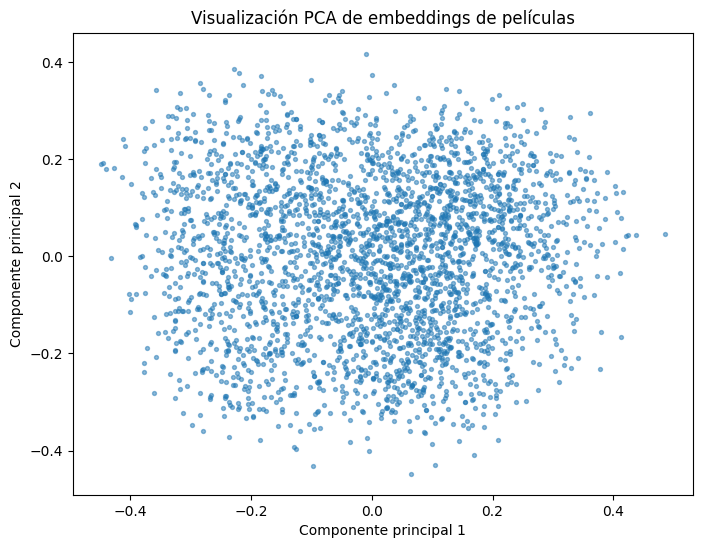

In [19]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_docs)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=8, alpha=0.5)
plt.title("Visualización PCA de embeddings de películas")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

La visualización PCA permite observar una proyección bidimensional de los embeddings generados para los documentos. Aunque PCA reduce la dimensionalidad y puede perder información, sirve como evidencia de experimentación adicional con las representaciones vectoriales.